# Coastal ocean preprocessing

In this notebook we explore some properties of the coastal ocean profile dataset, such as their distribution in time, in space, and their datatype

In [1]:
import os
import xarray as xr
import numpy as np

from coasty.config import PATH_DATASET
from data.mast_structure.transform_mast_data import *

In [11]:
ds = xr.open_dataset(PATH_DATASET)


datatype = ds["datatype"].values
for label in ["BO", "PF", "CT"]:
    print(f"{label}: {(datatype == label).sum():,}")


BO: 243,309
PF: 2,097
CT: 84,632


Profiles with measurements below bathymetry: 121,543 / 330,038 (36.8%)
Excess depth — min: 0.0 m, median: 3.0 m, max: 198.0 m
Profiles with excess > 100 m: 575 (0.17% of all profiles)


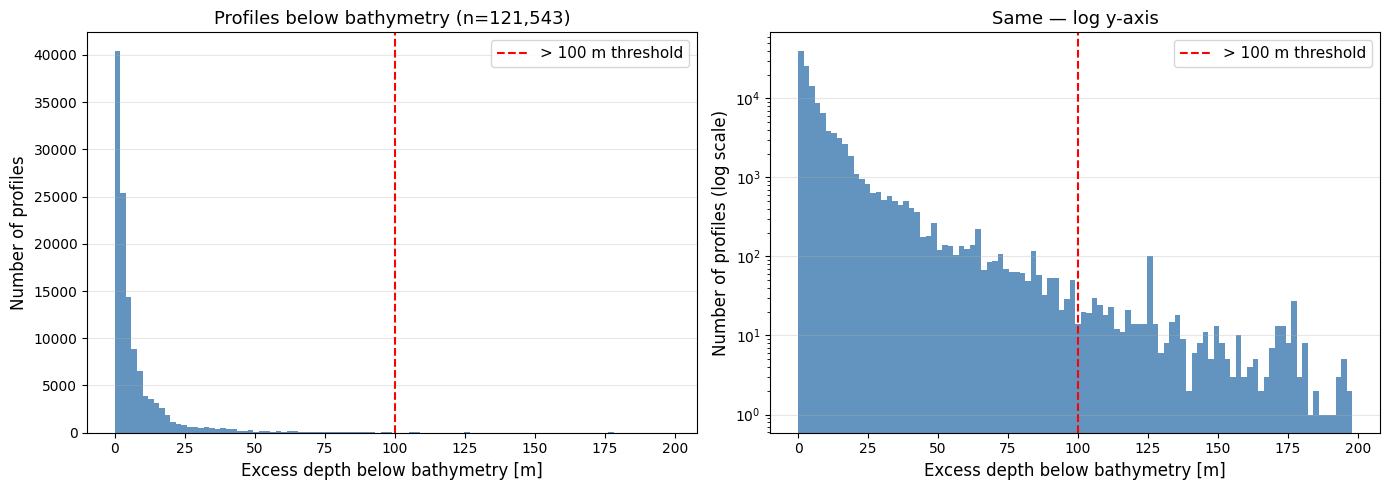

In [ ]:
import matplotlib.pyplot as plt

# Vectorised: deepest observation per profile (profile_end is 1-based)
all_ends = ds["profile_end"].values.astype(int) - 1
obs_depths = ds["obs_depths"].values
bathymetry = ds["bathymetry"].values  # negative values (depth below sea level)

max_obs_depth = obs_depths[all_ends]
# depth_gap > 0 means profile reaches below bathymetry
depth_gap = max_obs_depth - np.abs(bathymetry)

below_mask = depth_gap > 0
n_below = below_mask.sum()
print(f"Profiles with measurements below bathymetry: {n_below:,} / {len(depth_gap):,} ({100*n_below/len(depth_gap):.1f}%)")

excess = depth_gap[below_mask]
print(f"Excess depth — min: {excess.min():.1f} m, median: {np.median(excess):.1f} m, max: {excess.max():.1f} m")

n_above_50  = (excess > 50).sum()
n_above_100 = (excess > 100).sum()
print(f"Profiles with excess > 50 m:  {n_above_50:,}  ({100*n_above_50/len(depth_gap):.2f}% of all profiles)")
print(f"Profiles with excess > 100 m: {n_above_100:,} ({100*n_above_100/len(depth_gap):.2f}% of all profiles)")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.axvline(50,  color="orange", linestyle="--", linewidth=1.5, label="> 50 m threshold")
    ax.axvline(100, color="red",    linestyle="--", linewidth=1.5, label="> 100 m threshold")

axes[0].hist(excess, bins=100, color="steelblue", edgecolor="none", alpha=0.85)
axes[0].set_xlabel("Excess depth below bathymetry [m]", fontsize=12)
axes[0].set_ylabel("Number of profiles", fontsize=12)
axes[0].set_title(f"Profiles below bathymetry (n={n_below:,})", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(excess, bins=100, color="steelblue", edgecolor="none", alpha=0.85, log=True)
axes[1].set_xlabel("Excess depth below bathymetry [m]", fontsize=12)
axes[1].set_ylabel("Number of profiles (log scale)", fontsize=12)
axes[1].set_title("Same — log y-axis", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Detected obs dimension: values
Datatype source: datatype
Saved CSV to: /gpfs/scratch/acad/sail/ocean/data/copernicus_oxygen_profiles/INSITU_GLO_BGC_DISCRETE_MY_013_046/cmems_obs-ins_glo_bgc_my_easybgc_irr_202511/united_files/coastal_ocean/unified_300_coastal_bottom15_with_bathymetry.csv
   latitude [degrees_north]  longitude [degrees_east]            timestamp  \
0                   58.2598                   11.4357  2022-03-22 16:00:00   
1                   58.2598                   11.4357  2022-03-22 16:00:00   
2                   58.2598                   11.4357  2022-03-22 16:00:00   
3                   58.2598                   11.4357  2022-03-22 16:00:00   
4                   58.2598                   11.4357  2022-03-22 16:00:00   

   depth [m]  temperature [celsius degree]  salinity [psu]  bathymetry type  \
0        0.0                          4.86       24.570002  -64.673416   BO   
1        5.0                          4.83       25.250002  -64.673416   BO   
2     

In [15]:
ds_coastal_bottom15 = xr.open_dataset("/gpfs/projects/acad/bsmfc/coasty/data/coastal200m_full.nc")

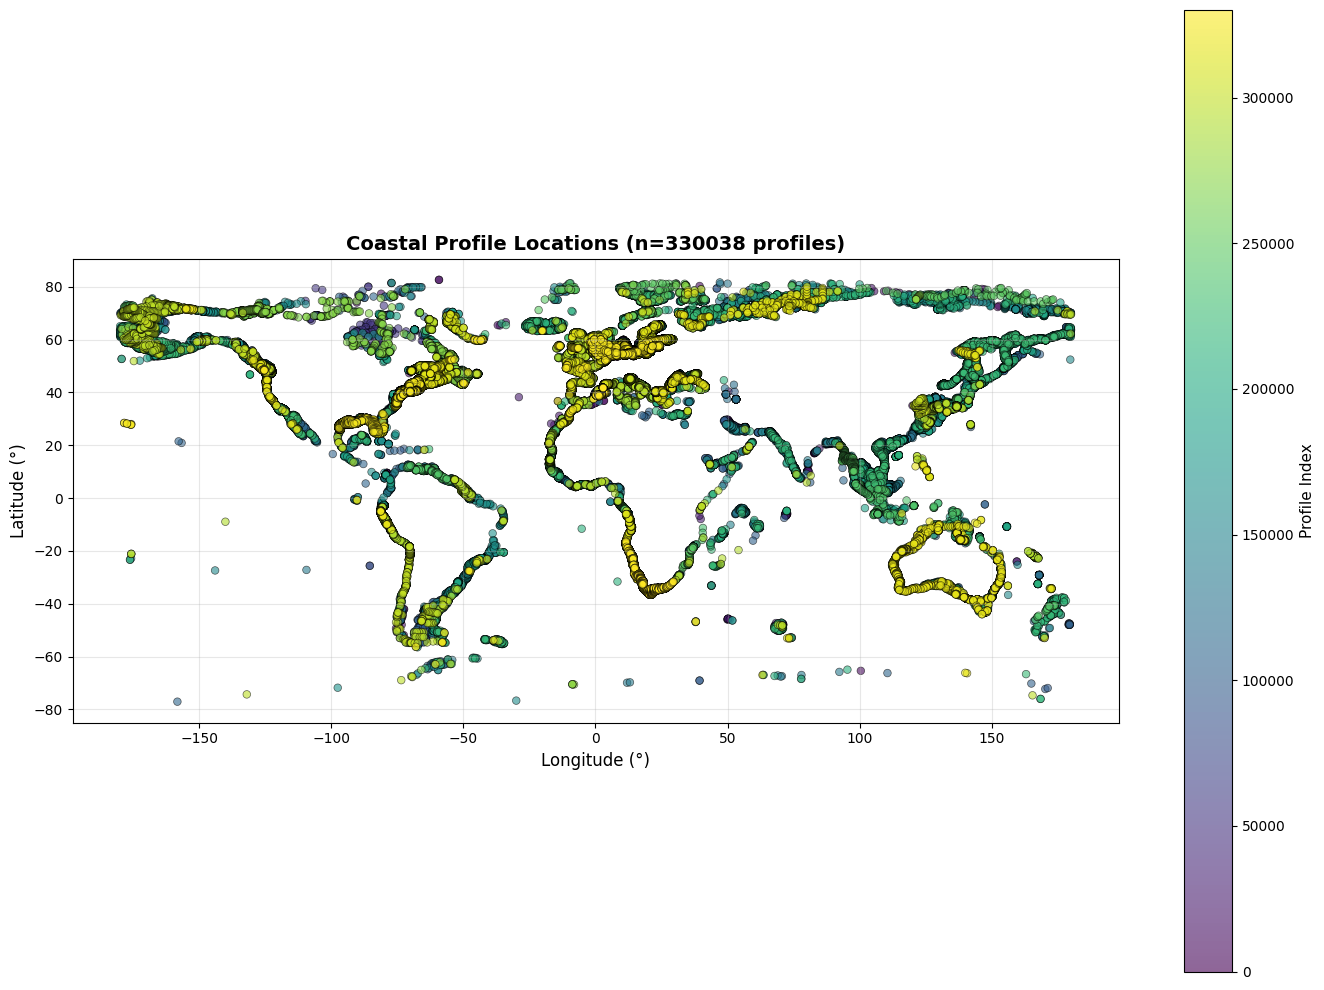

Total profiles plotted: 330038
Latitude range: -77.10° to 82.60°
Longitude range: -179.98° to 180.00°


In [16]:
import matplotlib.pyplot as plt

# Extract latitude and longitude from ds_coastal_bottom15
lats = ds_coastal_bottom15["latitude"].values
lons = ds_coastal_bottom15["longitude"].values

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 10))

# Plot scatter of profile locations
scatter = ax.scatter(lons, lats, c=range(len(lats)), cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidth=0.5)

# Labels and title
ax.set_xlabel('Longitude (°)', fontsize=12)
ax.set_ylabel('Latitude (°)', fontsize=12)
ax.set_title(f'Coastal Profile Locations (n={len(lats)} profiles)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Profile Index', fontsize=11)

# Set aspect ratio
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print(f"Total profiles plotted: {len(lats)}")
print(f"Latitude range: {lats.min():.2f}° to {lats.max():.2f}°")
print(f"Longitude range: {lons.min():.2f}° to {lons.max():.2f}°")

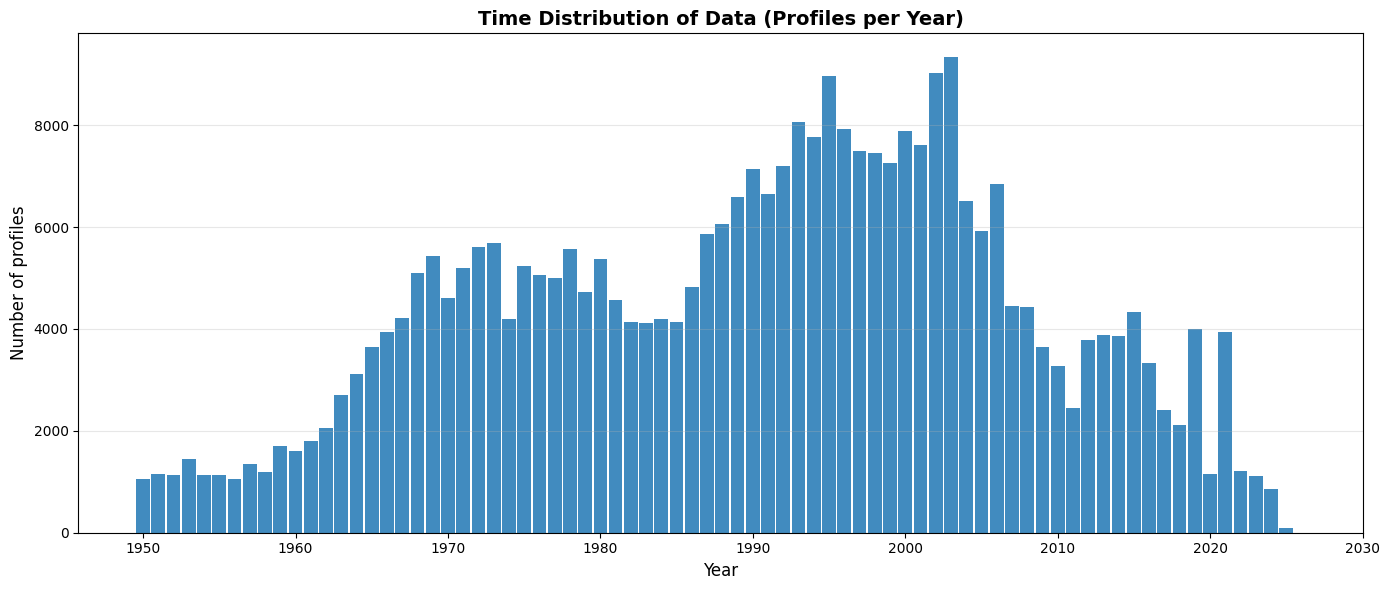

Years covered: 1950 to 2025
Total profiles: 330,038


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Build yearly distribution using profile timestamps (profile-wise)
profile_times = pd.to_datetime(ds_coastal_bottom15["obs_time"].values)
profile_years = profile_times.year

# Aggregate number of profiles per year (each profile counts once)
profiles_per_year = pd.Series(profile_years).value_counts().sort_index()

# Complete yearly index to include years with zero profiles
all_years = np.arange(profiles_per_year.index.min(), profiles_per_year.index.max() + 1)
profiles_per_year = profiles_per_year.reindex(all_years, fill_value=0)

# Plot yearly profile counts with x ticks every 10 years
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(profiles_per_year.index, profiles_per_year.values, width=0.9, color="tab:blue", alpha=0.85)

ax.set_title("Time Distribution of Data (Profiles per Year)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of profiles", fontsize=12)
ax.grid(axis="y", alpha=0.3)

# Show labels every 10 years while keeping yearly bars
tick_start = (int(profiles_per_year.index.min()) // 10) * 10
tick_end = ((int(profiles_per_year.index.max()) + 9) // 10) * 10
ax.set_xticks(np.arange(tick_start, tick_end + 1, 10))

plt.tight_layout()
plt.show()

print(f"Years covered: {int(profiles_per_year.index.min())} to {int(profiles_per_year.index.max())}")
print(f"Total profiles: {int(profiles_per_year.sum()):,}")